# BERT in Practice: Pre-trained Sentiment Models and the Fine-tuning Recipe

## 📚 Learning Objectives

By completing this notebook, you will:
- Use a pre-trained (already fine-tuned) DistilBERT model for sentiment classification
- Understand transfer learning with pre-trained models
- Walk through the Hugging Face fine-tuning recipe (Trainer/TrainingArguments code walkthrough — not executed here)
- Know what a fine-tuning run needs (labeled dataset, GPU time) before attempting one

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 4, lesson 01 "Attention and Transformers" — BERT is that encoder stack, already pretrained.

**Used later in:** Course 10 (AIAT 124) — Unit 2, lesson 02, which runs the fine-tuning recipe walked through here.

---

This notebook covers practical activities from **Course 07, Unit 4**:
- Fine-tuning BERT model for text classification using Hugging Face Transformers

---

## Introduction

**BERT (Bidirectional Encoder Representations from Transformers)** is a powerful pre-trained language model. Fine-tuning BERT allows us to adapt it for specific NLP tasks like text classification.


## 🌍 Why this matters: BERT changed what Google Search understands

On **25 October 2019**, one year after the BERT paper, Google announced it was using BERT in Search —
affecting "one in 10 searches in the U.S. in English" at launch. Their published example was the query
*"2019 brazil traveler to usa need a visa"*. The old system effectively ignored the small word **"to"** and
returned results about Americans travelling to Brazil; BERT, reading the sentence in both directions at
once, got the direction right. Google described it as one of the biggest leaps forward in the history of
Search (<https://blog.google/products/search/search-language-understanding-bert/>).

Nothing in that example required a rare word or a big vocabulary. It required **context** — which is
precisely what a bidirectional encoder gives you and what a bag of words (Unit 3) throws away.

**What goes wrong without this lesson.** Training a BERT-sized model from scratch costs GPU-months and a
corpus you do not have. Without transfer learning, a Saudi bank wanting Arabic complaint triage has two
options: hand-label a hundred thousand examples, or ship keyword rules. **Fine-tuning** collapses that to a
few hundred labelled examples and an afternoon, because the language understanding was already paid for by
somebody else.

The checkpoint you load below is that arrangement in action:
`distilbert-base-uncased-finetuned-sst-2-english` is DistilBERT
([arXiv:1910.01108](https://arxiv.org/abs/1910.01108)) already fine-tuned by a third party on the Stanford
Sentiment Treebank — 11,855 movie-review sentences and 215,154 labelled phrases (Socher et al., EMNLP 2013,
<https://nlp.stanford.edu/sentiment/>). Remember that corpus. It explains the next section.

## 📥 Inputs & 📤 Outputs

**Inputs:** three short example sentences defined in the code, and the pretrained checkpoint `distilbert-base-uncased-finetuned-sst-2-english` from Hugging Face (~250MB download on first run; cached afterwards).

**Outputs:** a real sentiment label and confidence score for each sentence, computed by the pretrained model — plus a printed fine-tuning recipe, which is a code walkthrough and is **not executed** here.

---

In [1]:
# Setup: scikit-learn for evaluation utilities + Hugging Face Transformers.
# The try/except lets the notebook degrade gracefully to printed instructions
# when the transformers library is not installed on this machine.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Try importing Hugging Face Transformers
try:
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
    from transformers import pipeline
    HAS_TRANSFORMERS = True
    print("✅ Hugging Face Transformers available!")
except ImportError:
    HAS_TRANSFORMERS = False
    print("⚠️  Transformers not available. Install with: pip install transformers")

# (No TensorFlow needed here: the transformers pipeline runs on its PyTorch backend.)
print("\n✅ Libraries imported!")

✅ Hugging Face Transformers available!

✅ Libraries imported!


## Part 1: Using a Pre-trained BERT-family Model with Hugging Face


In [2]:
# Use a pre-trained, already-fine-tuned sentiment model — zero training needed.
# This is the workhorse pattern of modern NLP: someone else spent the GPU-months;
# you download the checkpoint and get strong accuracy in three lines of code.

if HAS_TRANSFORMERS:
    print("=" * 60)
    print("Using a Pre-trained BERT-family Model")
    print("=" * 60)
    
    # DistilBERT is a smaller, faster BERT variant; this checkpoint is already
    # fine-tuned for sentiment analysis on the SST-2 dataset.
    model_name = "distilbert-base-uncased-finetuned-sst-2-english"
    
    print(f"\nLoading pretrained sentiment model: {model_name}")
    print("(a distilled BERT variant, already fine-tuned for sentiment)")
    print("Note: First run downloads the model (~250MB); later runs use the local cache")
    
    try:
        # Create a simple text classification pipeline
        classifier = pipeline("sentiment-analysis", model=model_name)
        
        # Test with sample text
        sample_texts = [
            "I love natural language processing!",
            "This course is challenging but interesting.",
            "Machine learning is difficult to understand."
        ]
        
        print("\n" + "-" * 60)
        print("Text Classification Results:")
        print("-" * 60)
        
        for text in sample_texts:
            result = classifier(text)[0]
            print(f"\nText: '{text}'")
            print(f"Label: {result['label']}, Score: {result['score']:.4f}")
        
        print("\n✅ Pre-trained BERT-family model (DistilBERT) used successfully!")
        
    except Exception as e:
        print(f"\nNote: Model download required. Error: {e}")
        print("To use BERT:")
        print("  1. Install: pip install transformers")
        print("  2. Model will download automatically on first use")
        print("  3. Requires internet connection for first run")
        
else:
    print("=" * 60)
    print("BERT with Hugging Face (Installation Required)")
    print("=" * 60)
    print("""
    To use BERT:
    
    1. Install Transformers:
       pip install transformers
    
    2. Load pre-trained model:
       from transformers import pipeline
       classifier = pipeline("sentiment-analysis")
       result = classifier("I love NLP!")
    
    3. Fine-tune for custom task:
       from transformers import AutoTokenizer, AutoModelForSequenceClassification
       tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
       model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased")
    """)

Using a Pre-trained BERT-family Model

Loading pretrained sentiment model: distilbert-base-uncased-finetuned-sst-2-english
(a distilled BERT variant, already fine-tuned for sentiment)
Note: First run downloads the model (~250MB); later runs use the local cache


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


------------------------------------------------------------
Text Classification Results:
------------------------------------------------------------

Text: 'I love natural language processing!'
Label: POSITIVE, Score: 0.9999

Text: 'This course is challenging but interesting.'
Label: POSITIVE, Score: 0.9970

Text: 'Machine learning is difficult to understand.'
Label: NEGATIVE, Score: 0.9992

✅ Pre-trained BERT-family model (DistilBERT) used successfully!


### Read the three predictions against each other

These are not three isolated results — they are three sentences that differ in one interesting way, and the
printed scores show what the model is actually keying on:

| Sentence | Label | Score |
|---|---|---|
| "I love natural language processing!" | POSITIVE | 0.9999 |
| "This course is challenging but interesting." | POSITIVE | 0.9970 |
| "Machine learning is difficult to understand." | NEGATIVE | 0.9992 |

Sentences 2 and 3 both describe something as hard. Sentence 2 pairs the difficulty with *interesting* and
comes out positive; sentence 3 has no counterweight and comes out **negative at 99.92% confidence** — even
though it is a neutral statement of fact, not a complaint about a product.

The conclusion those numbers support is narrow, and worth saying out loud: this model scores
*sentiment-in-movie-review-style-English*. It does not detect complaints, it has no "neutral" class, and it
has no way to say "I am not sure".

### Does this model ever say "I am not sure"?

Three sentences is not enough to see the shape of a classifier. Below we send eleven through the same
pipeline: four that carry a genuine opinion, five that are plain statements of fact with nothing to like or
dislike, and two written in Arabic — a language this `uncased` **English** checkpoint was never built for.
Then we plot the reported `P(POSITIVE)` for all eleven on one axis, next to how many word-piece tokens the
tokenizer chopped each sentence into.

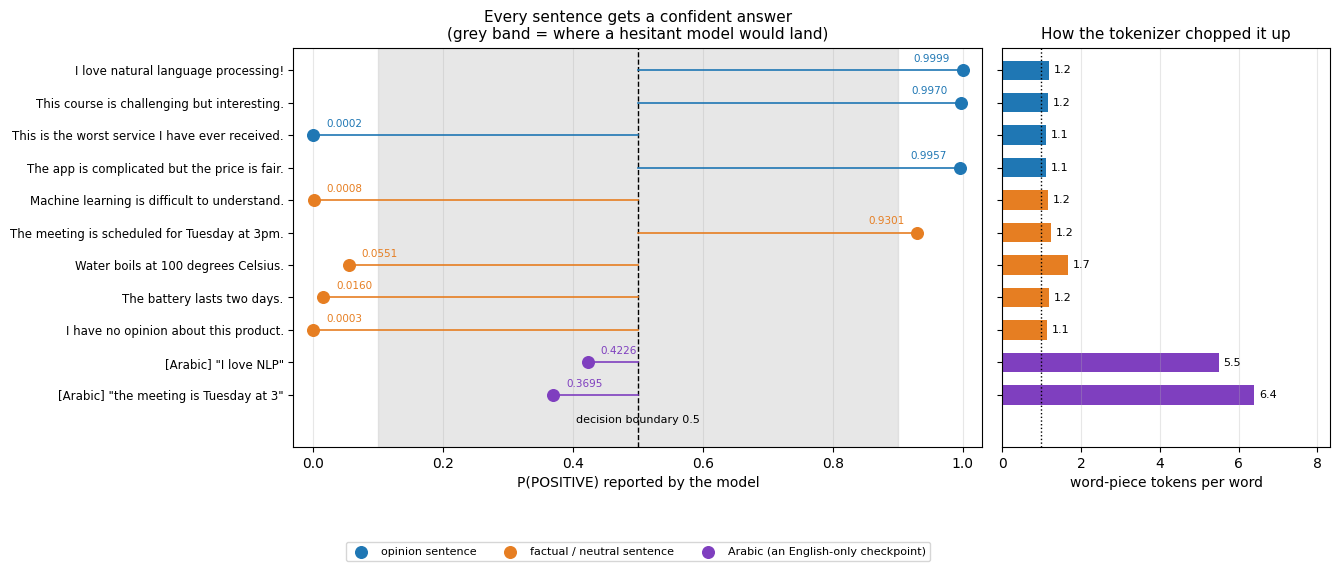

 P(POSITIVE)  label     tok/word  sentence
------------------------------------------------------------------------------
      0.9999  POSITIVE       1.2  I love natural language processing!
      0.9970  POSITIVE       1.2  This course is challenging but interesting.
      0.0002  NEGATIVE       1.1  This is the worst service I have ever received.
      0.9957  POSITIVE       1.1  The app is complicated but the price is fair.
      0.0008  NEGATIVE       1.2  Machine learning is difficult to understand.
      0.9301  POSITIVE       1.2  The meeting is scheduled for Tuesday at 3pm.
      0.0551  NEGATIVE       1.7  Water boils at 100 degrees Celsius.
      0.0160  NEGATIVE       1.2  The battery lasts two days.
      0.0003  NEGATIVE       1.1  I have no opinion about this product.
      0.4226  NEGATIVE       5.5  [Arabic] "I love NLP"
      0.3695  NEGATIVE       6.4  [Arabic] "the meeting is Tuesday at 3"

Sentences inside the 0.10-0.90 'uncertain' band: 2 of 11
   0.4226  [Arabic]

In [3]:
# WHAT: score eleven sentences and plot the confidence the model reports for each.
# WHY: a list of three scores hides the shape of the model's behaviour. On one axis
# you can see whether it ever hesitates — and on what kind of input.

import matplotlib.pyplot as plt

if HAS_TRANSFORMERS and "classifier" in globals():
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # (category, sentence, display label). Arabic is displayed by an English gloss so
    # the figure never depends on Arabic font shaping; the real string is scored.
    probe = [
        ("opinion", "I love natural language processing!", None),
        ("opinion", "This course is challenging but interesting.", None),
        ("opinion", "This is the worst service I have ever received.", None),
        ("opinion", "The app is complicated but the price is fair.", None),
        ("fact",    "Machine learning is difficult to understand.", None),
        ("fact",    "The meeting is scheduled for Tuesday at 3pm.", None),
        ("fact",    "Water boils at 100 degrees Celsius.", None),
        ("fact",    "The battery lasts two days.", None),
        ("fact",    "I have no opinion about this product.", None),
        ("arabic",  "أحب معالجة اللغة الطبيعية", '[Arabic] "I love NLP"'),
        ("arabic",  "الاجتماع يوم الثلاثاء الساعة الثالثة", '[Arabic] "the meeting is Tuesday at 3"'),
    ]

    rows = []
    for kind, text, alias in probe:
        r = classifier(text)[0]
        # The pipeline returns the winning label's score; convert to P(POSITIVE).
        p_pos = r["score"] if r["label"] == "POSITIVE" else 1.0 - r["score"]
        n_pieces = len(tokenizer(text)["input_ids"]) - 2      # drop [CLS] and [SEP]
        rows.append((kind, alias or text, p_pos, r["label"],
                     n_pieces / max(1, len(text.split()))))

    COL = {"opinion": "#1f77b4", "fact": "#e67e22", "arabic": "#7f3fbf"}
    NAME = {"opinion": "opinion sentence",
            "fact": "factual / neutral sentence",
            "arabic": "Arabic (an English-only checkpoint)"}
    y = np.arange(len(rows))[::-1]

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 6.0), sharey=True,
                                   gridspec_kw={"width_ratios": [2.1, 1]})
    # Grey band = the range where a hesitant model would put an uncertain sentence.
    axL.axvspan(0.10, 0.90, color="#bdbdbd", alpha=0.35, zorder=0)
    axL.axvline(0.5, color="black", lw=1, ls="--", zorder=1)
    for yy, (kind, label, p, lab, tpw) in zip(y, rows):
        axL.plot([0.5, p], [yy, yy], color=COL[kind], lw=1.2, zorder=2)
        axL.scatter(p, yy, s=70, color=COL[kind], zorder=3)
        axL.text(p + (0.02 if p < 0.5 else -0.02), yy + 0.26, f"{p:.4f}",
                 fontsize=7.5, ha="left" if p < 0.5 else "right", color=COL[kind])
    axL.set_yticks(y, [r[1] for r in rows], fontsize=8.5)
    axL.set_xlim(-0.03, 1.03)
    axL.set_ylim(-1.6, len(rows) - 0.3)
    axL.set_xlabel("P(POSITIVE) reported by the model")
    axL.set_title("Every sentence gets a confident answer\n"
                  "(grey band = where a hesitant model would land)", fontsize=11)
    axL.text(0.5, -0.85, "decision boundary 0.5", fontsize=8, ha="center")
    for k in COL:
        axL.scatter([], [], color=COL[k], label=NAME[k], s=70)
    axL.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.30), ncol=3)
    axL.grid(axis="x", alpha=0.3)

    axR.barh(y, [r[4] for r in rows], color=[COL[r[0]] for r in rows], height=0.6)
    axR.axvline(1.0, color="black", lw=1, ls=":")
    axR.set_xlabel("word-piece tokens per word")
    axR.set_title("How the tokenizer chopped it up", fontsize=11)
    axR.set_xlim(0, max(r[4] for r in rows) * 1.30)
    axR.grid(axis="x", alpha=0.3)
    for yy, r in zip(y, rows):
        axR.text(r[4] + 0.12, yy, f"{r[4]:.1f}", va="center", fontsize=8)
    fig.tight_layout()
    plt.show()

    print(f"{'P(POSITIVE)':>12}  {'label':<9}{'tok/word':>9}  sentence")
    print("-" * 78)
    for kind, label, p, lab, tpw in rows:
        print(f"{p:>12.4f}  {lab:<9}{tpw:>9.1f}  {label}")

    in_band = [r for r in rows if 0.10 < r[2] < 0.90]
    print(f"\nSentences inside the 0.10-0.90 'uncertain' band: {len(in_band)} of {len(rows)}")
    for r in in_band:
        print(f"   {r[2]:.4f}  {r[1]}")
    print("\nHow the Arabic sentence is tokenized (one Arabic letter per token):")
    print(" ", tokenizer.convert_ids_to_tokens(tokenizer(probe[-2][1])["input_ids"]))
else:
    print("Transformers or the pipeline is unavailable — skipping the confidence probe.")

**Read the left panel.** Each dot is one sentence, placed at the probability the model assigns to
POSITIVE; the dashed line is the 0.5 decision boundary and the grey band is where a model capable of
hesitating would put a sentence it found genuinely ambiguous.

Nine of the eleven dots fall outside the grey band, most of them pressed against 0.00 or 1.00. Look at the orange rows: *"The battery lasts two
days"* — a specification, not a review — is **NEGATIVE at 0.9840**; *"The meeting is scheduled for Tuesday
at 3pm"* is **POSITIVE at 0.9301**; *"I have no opinion about this product"*, which literally states the
absence of sentiment, is **NEGATIVE at 0.9997**. Those three sentences carry no sentiment at all, and the
model has no way to say so. Its output layer has exactly two exits.

**The one surprise is the purple pair.** The only two dots inside the grey band are the Arabic sentences —
at 0.42 and 0.37 the model looks almost undecided. That is not humility. The right panel shows why: an
English word costs about 1.1–1.7 word-pieces, while the Arabic sentences cost **5.5 and 6.4 pieces per
word**, because the `uncased` English vocabulary has no Arabic words in it and falls back to single
letters (the printed token list shows `'ا', '##ح', '##ب'` — letter by letter). The model is scoring
alphabet soup, drifts toward the middle for lack of any signal, and still commits to NEGATIVE. A number
near 0.5 does not mean "I am unsure"; here it means "I read nothing".

That is what the discussion below is about: a softmax score is a position relative to a boundary, not a
probability that the answer is right.

## 💬 Discuss

1. *"Machine learning is difficult to understand"* was called NEGATIVE at 0.9992. If this classifier sat on
   a Saudi telecom's feedback inbox, what would it do with *"the app is complicated but the price is
   fair"*? Which business decision would that mislabel, and who inside the company would notice first — if
   anyone?
2. The model reports 0.9970 and 0.9992. What *is* that number: a probability that the label is correct, a
   distance from the decision boundary, or a softmax output that would look equally confident on Arabic
   text the model cannot read? Describe the experiment that would tell you which.
3. Your client wants sentiment on Arabic reviews next month. Options: (a) machine-translate to English and
   use this model, (b) fine-tune a multilingual model on 500 labelled Arabic reviews, (c) fine-tune an
   Arabic-first model such as an ALLaM-family checkpoint
   ([arXiv:2407.15390](https://arxiv.org/abs/2407.15390)). Rank them by **cost**, then rank them again by
   **risk**. Where do the two rankings disagree, and which one should win?

## Part 2: The Fine-tuning Recipe (code walkthrough — not executed)

The cell below prints the standard Hugging Face fine-tuning recipe so you can read it line by line.
Nothing is trained here: a real fine-tuning run needs a labeled dataset and GPU time (see the scope
note in the learning objectives).

In [4]:
# The fine-tuning recipe, spelled out as a checklist and a code template.
# Printed rather than executed: real fine-tuning needs a labeled dataset and GPU
# time, but the structure below is exactly what you would run.

if HAS_TRANSFORMERS:
    print("=" * 60)
    print("Fine-tuning BERT for Text Classification")
    print("=" * 60)
    
    print("\nFine-tuning Process:")
    print("  1. Load pre-trained BERT model")
    print("  2. Add classification head (num_labels)")
    print("  3. Prepare tokenized dataset")
    print("  4. Train on custom dataset")
    print("  5. Evaluate on test set")
    
    print("\n✅ Fine-tuning Steps:")
    print("""
    # Example code structure:
    
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from transformers import Trainer, TrainingArguments
    
    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=2  # binary classification
    )
    
    # Tokenize data
    train_encodings = tokenizer(train_texts, truncation=True, padding=True)
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir='./results', num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=500,
        logging_dir='./logs'
    )
    
    # Trainer
    trainer = Trainer(
        model=model, args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset
    )
    
    # Fine-tune
    trainer.train()
    """)
    
    print("\n📋 That is the full fine-tuning recipe — NOT executed here (it needs a labeled dataset and GPU time)")
else:
    print("Note: Install transformers to fine-tune BERT models")

Fine-tuning BERT for Text Classification

Fine-tuning Process:
  1. Load pre-trained BERT model
  2. Add classification head (num_labels)
  3. Prepare tokenized dataset
  4. Train on custom dataset
  5. Evaluate on test set

✅ Fine-tuning Steps:

    # Example code structure:

    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    from transformers import Trainer, TrainingArguments

    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased", num_labels=2  # binary classification
    )

    # Tokenize data
    train_encodings = tokenizer(train_texts, truncation=True, padding=True)

    # Training arguments
    training_args = TrainingArguments(
        output_dir='./results', num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=500,
        logging_dir='./logs'
   

## Summary

### Key Concepts:
1. **BERT**: Bidirectional Encoder Representations from Transformers
   - Pre-trained on large text corpora
   - Understands context bidirectionally
   - Can be fine-tuned for specific tasks

2. **Fine-tuning**: Adapt pre-trained BERT for downstream tasks
   - Text classification (sentiment, topic, etc.)
   - Named Entity Recognition (NER)
   - Question Answering
   - Text summarization

3. **Transfer Learning**: Use knowledge from pre-trained models
   - Faster training with fewer data
   - Better performance than training from scratch
   - Leverage large-scale pre-training

### Best Practices:
- Use appropriate pre-trained model (BERT, DistilBERT, RoBERTa)
- Fine-tune learning rate (typically 2e-5 to 5e-5)
- Use appropriate batch size (16-32)
- Monitor training to avoid overfitting
- Evaluate on validation set

**Reference:** Course 07, Unit 4: "Deep Learning for NLP" - BERT fine-tuning practical content


## ⚠️ Where this breaks

**A checkpoint carries its training data with it, permanently.** `…-finetuned-sst-2-english` learned
sentiment from movie-review sentences. Point it at product reviews, medical notes, legal filings or support
tickets and it keeps answering — confidently — while measuring something slightly different from what you
asked. Domain shift in a pretrained model is silent: no error, just a wrong number.

**Three limits visible in this very notebook:**
- **Binary, forced choice.** POSITIVE or NEGATIVE, always. No neutral, no mixed, no abstention — which is
  why a factual sentence in Part 1 *had* to become NEGATIVE.
- **`uncased` and English.** The tokenizer lowercases and was built for English. Arabic input is not
  rejected; it is shredded into near-meaningless pieces and scored anyway.
- **Nothing was fine-tuned here.** Part 2 prints a recipe. Reading a recipe is not evidence that it works
  on your data, and this notebook has demonstrated nothing about fine-tuning except its shape.

**The assumption that must hold:** your text distribution resembles the fine-tuning corpus and your label
set matches the model's. If either is false you must fine-tune — and then you need labelled data, a
held-out test set drawn from *your* domain, and the evaluation discipline from Unit 3 rather than a
leaderboard number.

**When not to use BERT:**
- Keyword-separable task with plenty of labels → TF-IDF plus logistic regression (Unit 3) is far cheaper to
  serve, and you can read its weights.
- No labels at all and an open-ended task → a generative model with a prompt (lesson 05) is often a better
  first probe than any classifier.
- Hard on-device latency or memory limits → distillation and quantization come first; loading a 250 MB
  checkpoint per request is a deployment decision, not a free choice.
- You need to keep *facts* up to date → fine-tuning is the wrong tool for injecting knowledge. Retrieval is
  ([arXiv:2005.11401](https://arxiv.org/abs/2005.11401)), and it also makes the answer auditable.

## 🔭 State of the field (2026)

Adapting a model is now a three-rung ladder that you climb only as far as you must, and full fine-tuning has
fallen off the top of it. Rung one is **context**: retrieve the right text and put it in the prompt
([arXiv:2005.11401](https://arxiv.org/abs/2005.11401)) — cheapest, and the answer stays auditable. Rung two
is **parameters**, and it is parameter-*efficient*: LoRA adapters over a 4-bit quantized base, which is what
"fine-tuning" actually means today on a single consumer GPU
([arXiv:2305.14314](https://arxiv.org/abs/2305.14314)). Rung three is **preferences**, where a model is
trained on ranked outputs rather than labels (lesson 05). The full-weight `Trainer.train()` recipe in Part 2
is the honest picture of rung two before the efficiency tricks — and it is still the right first fine-tune
to run: a 250 MB checkpoint, minutes on a CPU, and a real accuracy number at the end.

Encoders did not retire either. When the job is a fixed label set at high volume, a small bidirectional
encoder is still the cheapest thing that works, and its modern descendants — instruction-conditioned
embedding and reranking models — are what feed the retrieval systems on rung one
([arXiv:2506.05176](https://arxiv.org/abs/2506.05176)). Learn the encoder recipe first; it makes every rung
above it legible.


## 📚 References

The BERT lineage — the original paper, the distilled model you just used, and how adaptation evolved after it:

1. Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL 2019. [arXiv:1810.04805](https://arxiv.org/abs/1810.04805)
2. Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a Distilled Version of BERT: Smaller, Faster, Cheaper and Lighter*. [arXiv:1910.01108](https://arxiv.org/abs/1910.01108)
3. Rogers, A., Kovaleva, O., & Rumshisky, A. (2020). *A Primer in BERTology: What We Know About How BERT Works*. TACL, 8. [arXiv:2002.12327](https://arxiv.org/abs/2002.12327)
4. Hu, E. J., Shen, Y., Wallis, P., et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)
5. Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS 2020. [arXiv:2005.11401](https://arxiv.org/abs/2005.11401) — the alternative to fine-tuning when what you need to change is *facts*, not behaviour.
6. Dettmers, T., Pagnoni, A., Holtzman, A., & Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs*. [arXiv:2305.14314](https://arxiv.org/abs/2305.14314) — adapters over a 4-bit base; what "fine-tuning" means on one consumer GPU.
7. Bari, M. S., Alnumay, Y., Alzahrani, N. A., Alotaibi, N. M., Alyahya, H. A., et al. (2024). *ALLaM: Large Language Models for Arabic and English*. [arXiv:2407.15390](https://arxiv.org/abs/2407.15390) — the Arabic-and-English alternative to the English `uncased` checkpoint used above.
8. Zhang, Y., Li, M., Long, D., Zhang, X., Lin, H., et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. [arXiv:2506.05176](https://arxiv.org/abs/2506.05176) — where the encoder went: instruction-conditioned embedding and reranking models.
